In [1]:
# Cài đặt thư viện
import torch

TORCH_version = torch.__version__.split("+")[0]
CUDA_version = (
    "cpu"
    if not torch.cuda.is_available()
    else f"cu{torch.version.cuda.replace('.', '')}"
)

print(f"Torch version: {TORCH_version}")
print(f"CUDA version: {CUDA_version}")

!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA_version}.html
!pip install -q torch-geometric


Torch version: 2.11.0
CUDA version: cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00


In [2]:
import os, gc, gzip, urllib.request
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from sklearn.metrics import accuracy_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device: cuda
PyTorch: 2.11.0+cu128


In [3]:
# Tải dữ liệu từ snap
EDGE_URL  = 'https://snap.stanford.edu/data/soc-pokec-relationships.txt.gz'
PROF_URL  = 'https://snap.stanford.edu/data/soc-pokec-profiles.txt.gz'
EDGE_FILE = 'pokec_edges.txt.gz'
PROF_FILE = 'pokec_profiles.txt.gz'

def download_if_needed(url, fname):
    if not os.path.exists(fname):
        print(f'Đang tải {fname} ...')
        urllib.request.urlretrieve(url, fname)
        print(f'Tải xong: {fname}')
    else:
        print(f'Đã có: {fname}')

download_if_needed(EDGE_URL, EDGE_FILE)
download_if_needed(PROF_URL, PROF_FILE)

Đang tải pokec_edges.txt.gz ...
Tải xong: pokec_edges.txt.gz
Đang tải pokec_profiles.txt.gz ...
Tải xong: pokec_profiles.txt.gz


In [4]:
# Đọc cạnh và xây dựng đồ thị
print('Đọc danh sách cạnh ...')
src_list, dst_list = [], []

with gzip.open(EDGE_FILE, 'rt') as f:
    for line in f:
        u, v = line.strip().split()
        src_list.append(int(u))
        dst_list.append(int(v))

src_arr = np.array(src_list, dtype=np.int32)
dst_arr = np.array(dst_list, dtype=np.int32)
del src_list, dst_list
gc.collect()

# Re-index từ 0
all_nodes = np.unique(np.concatenate([src_arr, dst_arr]))
node2idx  = {n: i for i, n in enumerate(all_nodes)}
N = len(all_nodes)
src_idx = np.array([node2idx[u] for u in src_arr], dtype=np.int32)
dst_idx = np.array([node2idx[v] for v in dst_arr], dtype=np.int32)
del src_arr, dst_arr
gc.collect()

E = len(src_idx)
density = E / (N * (N - 1))

print(f'\nTHỐNG KÊ ĐỒ THỊ')
print(f'  Số đỉnh (N)  : {N:,}')
print(f'  Số cạnh (E)  : {E:,}')
print(f'  Mật độ       : {density:.2e}')

Đọc danh sách cạnh ...

THỐNG KÊ ĐỒ THỊ
  Số đỉnh (N)  : 1,632,803
  Số cạnh (E)  : 30,622,564
  Mật độ       : 1.15e-05


In [5]:
# Tính bậc vào và bậc ra mỗi đỉnh
out_deg = np.bincount(src_idx, minlength=N).astype(np.float32)
in_deg  = np.bincount(dst_idx, minlength=N).astype(np.float32)
print(f'In-degree  — max: {in_deg.max():.0f}, mean: {in_deg.mean():.2f}')
print(f'Out-degree — max: {out_deg.max():.0f}, mean: {out_deg.mean():.2f}')

In-degree  — max: 13733, mean: 18.75
Out-degree — max: 8763, mean: 18.75


In [6]:
# Approximate Personalized PageRank (APPr) — Gán nhãn
# --- Xây dựng ma trận chuyển tiếp thưa
data_vals = np.ones(E, dtype=np.float32)
# Chuẩn hóa theo bậc ra (D^{-1} A)
out_deg_safe = np.where(out_deg == 0, 1, out_deg)
norm_vals = data_vals / out_deg_safe[src_idx]

P = sp.csr_matrix(
    (norm_vals, (src_idx, dst_idx)),
    shape=(N, N),
    dtype=np.float32
)
del norm_vals, data_vals
gc.collect()
print('Ma trận chuyển tiếp P đã xây dựng (sparse CSR)')

# --- APPr Power Iteration (alpha = 0.15, K = 5 bước) ---
# Score xấp xỉ: r = alpha * e + (1-alpha) * P^T r   (column-stochastic view)
# Ở đây dùng in-degree làm seed (mỗi đỉnh nhận seed tỉ lệ in-degree)
alpha = 0.15
K = 5

# Dùng in_deg làm vector khởi tạo (float64 để ổn định)
r = in_deg.astype(np.float64)
r_norm = r / (r.sum() + 1e-12)

print(f'Chạy APPr với alpha={alpha}, K={K} bước ...')
for k in range(K):
    r_norm = alpha * (in_deg / (in_deg.sum() + 1e-12)) + (1 - alpha) * P.T.dot(r_norm)
    if k % 1 == 0:
        print(f'  Bước {k+1}/{K} — min={r_norm.min():.4e}, max={r_norm.max():.4e}')

appr_score = r_norm.astype(np.float32)
del r, r_norm, P
gc.collect()
print('APPr hoàn tất')

Ma trận chuyển tiếp P đã xây dựng (sparse CSR)
Chạy APPr với alpha=0.15, K=5 bước ...
  Bước 1/5 — min=0.0000e+00, max=4.8349e-04
  Bước 2/5 — min=0.0000e+00, max=4.4863e-04
  Bước 3/5 — min=0.0000e+00, max=4.3879e-04
  Bước 4/5 — min=0.0000e+00, max=4.2583e-04
  Bước 5/5 — min=0.0000e+00, max=4.1879e-04
APPr hoàn tất


In [7]:
# --- Gán nhãn dựa trên phân vị APPr score ---
# 0: clone/spam   (< p40)
# 1: casual       (p40 – p75)
# 2: potential    (p75 – p95)
# 3: influencer   (>= p95)

p40 = np.percentile(appr_score, 10)
p75 = np.percentile(appr_score, 75)
p95 = np.percentile(appr_score, 95)

labels = np.zeros(N, dtype=np.int64)
labels[appr_score >= p40] = 1
labels[appr_score >= p75] = 2
labels[appr_score >= p95] = 3

label_names = {0: 'Clone/Spam', 1: 'Casual', 2: 'Potential', 3: 'Influencer'}
cnt = Counter(labels.tolist())
print('\n📌 Phân bố nhãn APPr:')
for k, name in label_names.items():
    print(f'  {k} — {name:15s}: {cnt[k]:>8,} đỉnh  ({cnt[k]/N*100:.1f}%)')


📌 Phân bố nhãn APPr:
  0 — Clone/Spam     :  163,281 đỉnh  (10.0%)
  1 — Casual         : 1,061,321 đỉnh  (65.0%)
  2 — Potential      :  326,560 đỉnh  (20.0%)
  3 — Influencer     :   81,641 đỉnh  (5.0%)


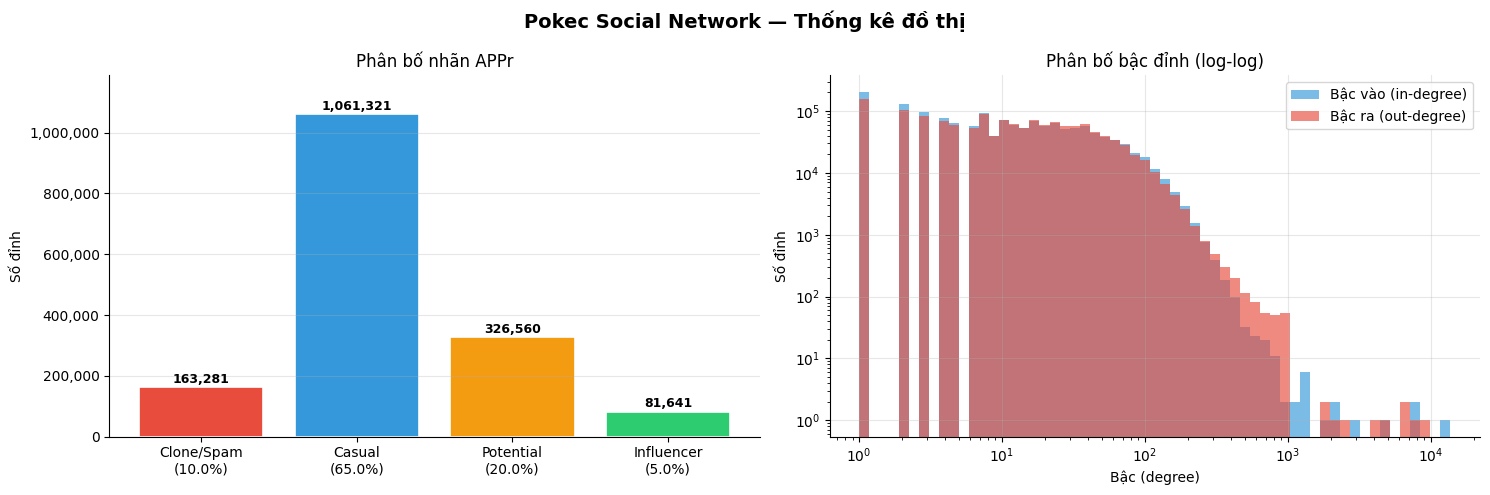

In [8]:
# Biểu đồ 1: phân bố nhãn
# Biểu đồ 2: phân bố bậc
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pokec Social Network — Thống kê đồ thị', fontsize=14, fontweight='bold')

# --- Biểu đồ 1: Số lượng từng nhãn ---
ax1 = axes[0]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
bar_labels = [f"{label_names[k]}\n({cnt[k]/N*100:.1f}%)" for k in range(4)]
bars = ax1.bar(bar_labels, [cnt[k] for k in range(4)], color=colors, edgecolor='white', linewidth=1.2)
for bar, k in zip(bars, range(4)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + N*0.003,
             f'{cnt[k]:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Phân bố nhãn APPr', fontsize=12)
ax1.set_ylabel('Số đỉnh')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, max(cnt.values()) * 1.12)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# --- Biểu đồ 2: Phân bố bậc vào / bậc ra (log-scale histogram) ---
ax2 = axes[1]
bins = np.logspace(0, np.log10(max(in_deg.max(), out_deg.max()) + 1), 60)
ax2.hist(in_deg[in_deg > 0],  bins=bins, alpha=0.65, color='#3498db', label='Bậc vào (in-degree)')
ax2.hist(out_deg[out_deg > 0], bins=bins, alpha=0.65, color='#e74c3c', label='Bậc ra (out-degree)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Phân bố bậc đỉnh (log-log)', fontsize=12)
ax2.set_xlabel('Bậc (degree)')
ax2.set_ylabel('Số đỉnh')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


## PHẦN 2 — Xây dựng đặc trưng node từ APPr (không dùng Bayes)


In [9]:
# Tạo ma trận đặc trưng trực tiếp từ các chỉ số đồ thị + APPr score
# Không sử dụng Naive Bayes — đặc trưng thuần từ cấu trúc đồ thị
#
#   x1 = in_degree                    (số người follow)
#   x2 = log(in_degree + 1)           (ổn định phân phối lệch)
#   x3 = in_deg / (in_deg+out_deg+1)  (tỷ lệ được follow)
#   x4 = appr_score                   (điểm APPr)
#   x5 = in_deg - out_deg             (chênh lệch bậc)

print('Tạo ma trận đặc trưng (APPr-only) ...')
x1 = in_deg
x2 = np.log1p(in_deg)
x3 = in_deg / (in_deg + out_deg + 1.0)
x4 = appr_score
x5 = in_deg - out_deg

X_raw = np.column_stack([x1, x2, x3, x4, x5]).astype(np.float32)
print(f'Shape X_raw: {X_raw.shape}')

# Chuẩn hóa Z-score thủ công (không dùng sklearn StandardScaler)
mean_ = X_raw.mean(axis=0)
std_  = X_raw.std(axis=0) + 1e-8
X_feat = ((X_raw - mean_) / std_).astype(np.float32)
print(f'Feature matrix shape: {X_feat.shape}  (5 đặc trưng từ đồ thị + APPr)')

del X_raw
gc.collect()


Tạo ma trận đặc trưng (APPr-only) ...
Shape X_raw: (1632803, 5)
Feature matrix shape: (1632803, 5)  (5 đặc trưng từ đồ thị + APPr)


3112

In [10]:
# Xây dựng PyG Data object — SPARSE edge_index
# Chỉ giữ cạnh kết nối với node label >= 1, tối đa 3M cạnh

rng = np.random.default_rng(42)
MAX_EDGES = 3_000_000

keep_mask = (labels[src_idx] >= 1) | (labels[dst_idx] >= 1)
s_keep = src_idx[keep_mask]
d_keep = dst_idx[keep_mask]
print(f'Cạnh sau lọc: {len(s_keep):,}')

if len(s_keep) > MAX_EDGES:
    chosen = rng.choice(len(s_keep), MAX_EDGES, replace=False)
    s_keep = s_keep[chosen]
    d_keep = d_keep[chosen]
    print(f'Đã sample xuống {MAX_EDGES:,} cạnh để tiết kiệm VRAM')

edge_index  = torch.tensor(np.vstack([s_keep, d_keep]), dtype=torch.long)
node_feats  = torch.tensor(X_feat, dtype=torch.float32)
node_labels = torch.tensor(labels, dtype=torch.long)

# Train (20%) / Val (10%) / Test (70%)
train_mask_np = rng.random(N) < 0.20
train_idx = np.where(train_mask_np)[0]
rest_idx  = np.where(~train_mask_np)[0]
val_idx   = rng.choice(rest_idx, size=int(0.1 * N), replace=False)
test_mask_arr = np.ones(N, dtype=bool)
test_mask_arr[train_idx] = False
test_mask_arr[val_idx]   = False

train_mask_t = torch.zeros(N, dtype=torch.bool)
val_mask_t   = torch.zeros(N, dtype=torch.bool)
test_mask_t  = torch.zeros(N, dtype=torch.bool)
train_mask_t[train_idx] = True
val_mask_t[val_idx]     = True
test_mask_t[test_mask_arr] = True

data = Data(
    x=node_feats,
    edge_index=edge_index,
    y=node_labels,
    train_mask=train_mask_t,
    val_mask=val_mask_t,
    test_mask=test_mask_t
)
print(data)
del s_keep, d_keep, X_feat
gc.collect()


Cạnh sau lọc: 30,608,500
Đã sample xuống 3,000,000 cạnh để tiết kiệm VRAM
Data(x=[1632803, 5], edge_index=[2, 3000000], y=[1632803], train_mask=[1632803], val_mask=[1632803], test_mask=[1632803])


0

## PHẦN 3 — Huấn luyện GAT


In [11]:
# Mô hình GAT 3 lớp với BatchNorm và Residual Connection
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

class ImprovedGAT(nn.Module):
    def __init__(self, in_feats, hidden=64, out_classes=4, heads=8, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_feats, hidden, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden*heads, hidden, heads=heads, dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden*heads, out_classes, heads=1, dropout=dropout, concat=False)
        self.bn1 = nn.BatchNorm1d(hidden*heads)
        self.bn2 = nn.BatchNorm1d(hidden*heads)
        self.residual = nn.Linear(in_feats, out_classes)

    def forward(self, x, edge_index):
        residual = self.residual(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = self.conv3(x, edge_index)
        return x + residual

IN_FEATS = data.num_node_features  # 5
model = ImprovedGAT(
    in_feats=IN_FEATS,
    hidden=16,
    heads=3,
    dropout=0.25
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTổng tham số: {total_params:,}')


ImprovedGAT(
  (conv1): GATConv(5, 16, heads=3)
  (conv2): GATConv(48, 16, heads=3)
  (conv3): GATConv(48, 4, heads=1)
  (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual): Linear(in_features=5, out_features=4, bias=True)
)

Tổng tham số: 3,252


In [12]:
# Di chuyển dữ liệu lên GPU
data = data.to(DEVICE)
print(f'Data trên: {data.x.device}')

if DEVICE.type == 'cuda':
    allocated = torch.cuda.memory_allocated(DEVICE) / 1e9
    print(f'VRAM đã dùng: {allocated:.2f} GB')

Data trên: cuda:0
VRAM đã dùng: 0.10 GB


In [13]:
# Hàm evaluate
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        loss = criterion_weighted(logits[mask], data.y[mask]).item()
        preds  = logits[mask].argmax(dim=1).cpu().numpy()
        truths = data.y[mask].cpu().numpy()
        acc = accuracy_score(truths, preds)
        f1  = f1_score(truths, preds, average='macro', zero_division=0)
    return loss, acc, f1

# Class weights (tăng trọng số cho Influencer)
class_weights = torch.tensor([0.7, 0.9, 2.8, 7.5]).to(DEVICE)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

# AMP chỉ bật khi có CUDA, tự động fallback về CPU
import contextlib
from torch.amp import autocast, GradScaler
use_amp = DEVICE.type == 'cuda'
scaler  = GradScaler('cuda') if use_amp else None
amp_ctx = autocast('cuda') if use_amp else contextlib.nullcontext()
print(f'AMP (mixed precision): {"BẬT" if use_amp else "TẮT (CPU mode)"}')

early_stopping_patience = 100
best_val_f1 = 0.0
best_model_state = None
counter = 0

history = {
    'epoch': [], 'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []
}

EPOCHS = 500
print(f'Bắt đầu huấn luyện tối đa {EPOCHS} epochs ...\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    with amp_ctx:
        logits = model(data.x, data.edge_index)
        loss = criterion_weighted(logits[data.train_mask], data.y[data.train_mask])

    if use_amp:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    t_loss, t_acc, t_f1 = evaluate(data.train_mask)
    v_loss, v_acc, v_f1 = evaluate(data.val_mask)
    scheduler.step(v_f1)

    history['epoch'].append(epoch)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v_f1)

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | '
              f'Val Acc: {v_acc:.4f} | Val F1: {v_f1:.4f} | LR: {lr:.6f}')

    if counter >= early_stopping_patience:
        print(f'\nEarly stopping tại epoch {epoch}!')
        break

    if use_amp:
        torch.cuda.empty_cache()

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f'\n=== HOÀN TẤT ===')
print(f'Best Validation Macro F1: {best_val_f1:.4f}')


AMP (mixed precision): BẬT
Bắt đầu huấn luyện tối đa 500 epochs ...

Epoch   1 | Train Loss: 1.6036 | Val Loss: 1.6087 | Val Acc: 0.0361 | Val F1: 0.1109 | LR: 0.003000
Epoch  10 | Train Loss: 1.1927 | Val Loss: 1.1956 | Val Acc: 0.2401 | Val F1: 0.2901 | LR: 0.003000
Epoch  20 | Train Loss: 0.9749 | Val Loss: 0.9779 | Val Acc: 0.5799 | Val F1: 0.6157 | LR: 0.003000
Epoch  30 | Train Loss: 0.8471 | Val Loss: 0.8502 | Val Acc: 0.6992 | Val F1: 0.7227 | LR: 0.003000
Epoch  40 | Train Loss: 0.7407 | Val Loss: 0.7436 | Val Acc: 0.6756 | Val F1: 0.5442 | LR: 0.003000
Epoch  50 | Train Loss: 0.6763 | Val Loss: 0.6789 | Val Acc: 0.6902 | Val F1: 0.5547 | LR: 0.003000
Epoch  60 | Train Loss: 0.6429 | Val Loss: 0.6452 | Val Acc: 0.6950 | Val F1: 0.5603 | LR: 0.001500
Epoch  70 | Train Loss: 0.6304 | Val Loss: 0.6326 | Val Acc: 0.7403 | Val F1: 0.7174 | LR: 0.001500
Epoch  80 | Train Loss: 0.6200 | Val Loss: 0.6222 | Val Acc: 0.6998 | Val F1: 0.5635 | LR: 0.000750
Epoch  90 | Train Loss: 0.6138 

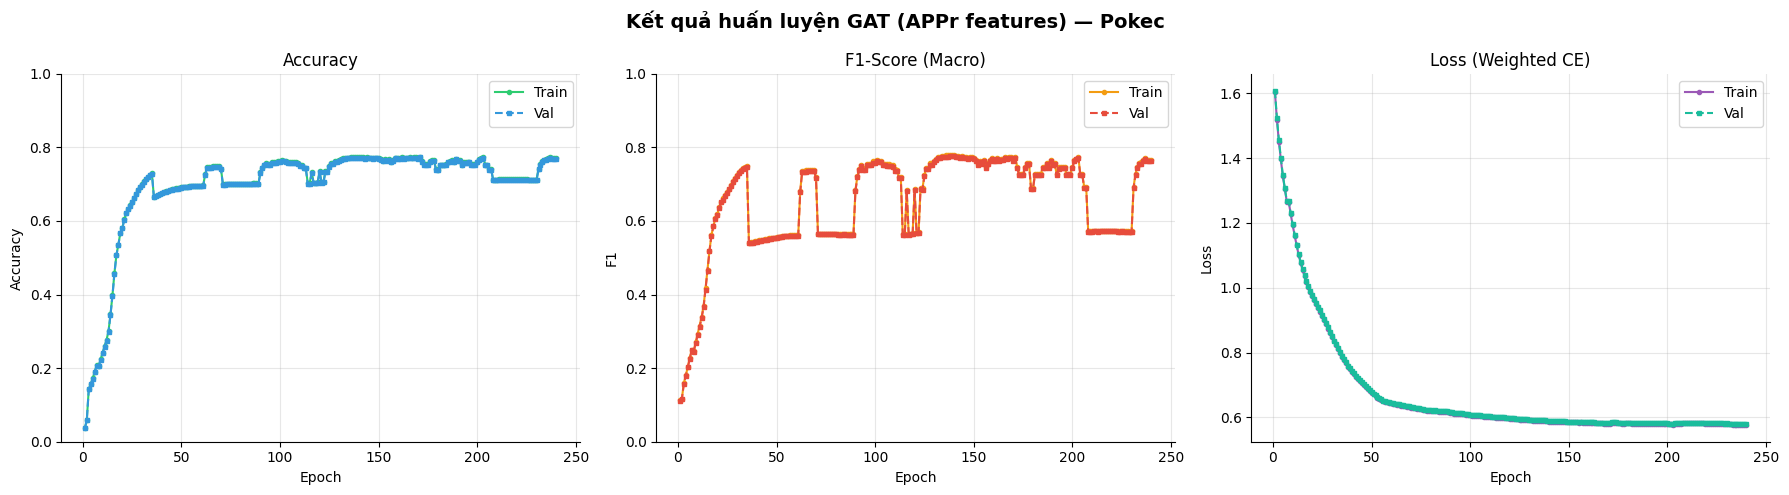

Đã lưu: training_curves.png


In [14]:
# Biểu đồ 1: Accuracy / F1 / Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Kết quả huấn luyện GAT (APPr features) — Pokec', fontsize=14, fontweight='bold')
epochs_x = history['epoch']

ax = axes[0]
ax.plot(epochs_x, history['train_acc'], 'o-', color='#2ecc71', label='Train', markersize=3)
ax.plot(epochs_x, history['val_acc'],   's--', color='#3498db', label='Val', markersize=3)
ax.set_title('Accuracy', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(epochs_x, history['train_f1'], 'o-', color='#f39c12', label='Train', markersize=3)
ax.plot(epochs_x, history['val_f1'],   's--', color='#e74c3c', label='Val', markersize=3)
ax.set_title('F1-Score (Macro)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('F1')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)

ax = axes[2]
ax.plot(epochs_x, history['train_loss'], 'o-', color='#9b59b6', label='Train', markersize=3)
ax.plot(epochs_x, history['val_loss'],   's--', color='#1abc9c', label='Val', markersize=3)
ax.set_title('Loss (Weighted CE)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: training_curves.png')


In [15]:
# Lấy điểm Influencer từ GAT output
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=1).cpu().numpy()

gat_score = probs[:, 3]  # P(Influencer)

# Hybrid score: 40% GAT + 60% in-degree (chuẩn hóa)
in_deg_normalized = in_deg / (in_deg.max() + 1e-9)
hybrid_score = 0.4 * gat_score + 0.6 * in_deg_normalized

top20_idx = np.argsort(hybrid_score)[::-1][:20]
orig_ids  = list(all_nodes)

print('TOP 20 INFLUENCER (GAT + APPr, không dùng Bayes):')
print(f'{"Rank":>4}  {"Node ID":>12}  {"In-deg":>8}  {"Out-deg":>8}  {"APPr":>10}  {"P(Influencer)":>13}')
print('-' * 70)
for rank, idx in enumerate(top20_idx, 1):
    print(f'{rank:>4}  {orig_ids[idx]:>12}  {int(in_deg[idx]):>8,}  {int(out_deg[idx]):>8,}  '
          f'{appr_score[idx]:>10.4e}  {gat_score[idx]:>13.4f}')


TOP 20 INFLUENCER (GAT + APPr, không dùng Bayes):
Rank       Node ID    In-deg   Out-deg        APPr  P(Influencer)
----------------------------------------------------------------------
   1          5935    13,733     6,785  4.1879e-04         1.0000
   2          5867     8,215     8,763  2.0995e-04         1.0000
   3          1891     7,613     7,564  1.9636e-04         1.0000
   4          6228     4,855     3,878  1.1881e-04         1.0000
   5          1830     2,910     1,757  6.5386e-05         1.0000
   6         25994     2,235     4,535  5.9564e-05         1.0000
   7         57918     2,015        14  5.3037e-05         1.0000
   8          8413     1,889     2,315  6.8946e-05         1.0000
   9         86306     1,413        63  4.2838e-05         1.0000
  10         59973     1,354         0  3.5948e-05         1.0000
  11         67180     1,307         3  2.3417e-05         1.0000
  12         27509     1,289         6  3.8115e-05         1.0000
  13         88982   

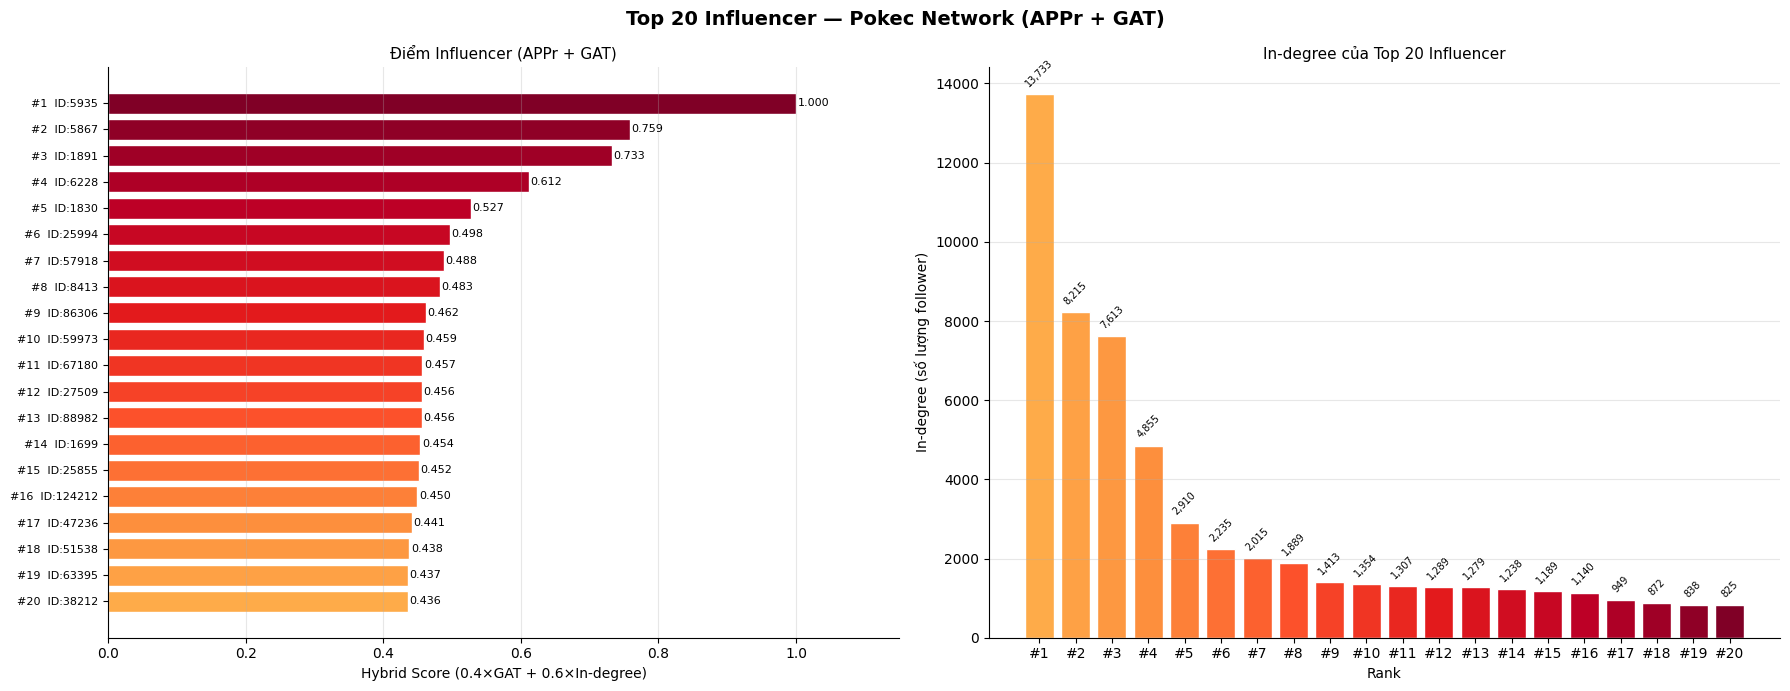

Đã lưu: top20_influencer.png


In [16]:
# Biểu đồ 2: Top 20 Influencer
top20_scores = hybrid_score[top20_idx]
top20_indeg  = in_deg[top20_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 20 Influencer — Pokec Network (APPr + GAT)', fontsize=14, fontweight='bold')

colors_top = plt.cm.YlOrRd(np.linspace(0.4, 1.0, 20))[::-1]

ax1 = axes[0]
bars = ax1.barh(range(20, 0, -1), top20_scores, color=colors_top, edgecolor='white')
ax1.set_yticks(range(20, 0, -1))
ax1.set_yticklabels([f'#{i+1}  ID:{orig_ids[top20_idx[i]]}' for i in range(20)], fontsize=8)
for bar, score in zip(bars, top20_scores):
    ax1.text(score + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=8)
ax1.set_xlabel('Hybrid Score (0.4×GAT + 0.6×In-degree)')
ax1.set_title('Điểm Influencer (APPr + GAT)', fontsize=11)
ax1.set_xlim(0, top20_scores.max() * 1.15)
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
rank_labels = [f'#{i+1}' for i in range(20)]
bar2 = ax2.bar(rank_labels, top20_indeg, color=colors_top[::-1], edgecolor='white')
for bar, v in zip(bar2, top20_indeg):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + top20_indeg.max()*0.01,
             f'{int(v):,}', ha='center', va='bottom', fontsize=7, rotation=45)
ax2.set_xlabel('Rank')
ax2.set_ylabel('In-degree (số lượng follower)')
ax2.set_title('In-degree của Top 20 Influencer', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('top20_influencer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: top20_influencer.png')


In [17]:
from google.colab import files
files.download('training_curves.png')
files.download('top20_influencer.png')
print('Đã tải xong 2 biểu đồ!')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đã tải xong 2 biểu đồ!


Kết quả trên Test Set:
              precision    recall  f1-score   support

  Clone/Spam       1.00      0.65      0.79    114527
      Casual       0.90      0.76      0.82    742718
   Potential       0.51      0.85      0.64    228449
  Influencer       0.82      0.92      0.87     57222

    accuracy                           0.77   1142916
   macro avg       0.81      0.79      0.78   1142916
weighted avg       0.83      0.77      0.78   1142916



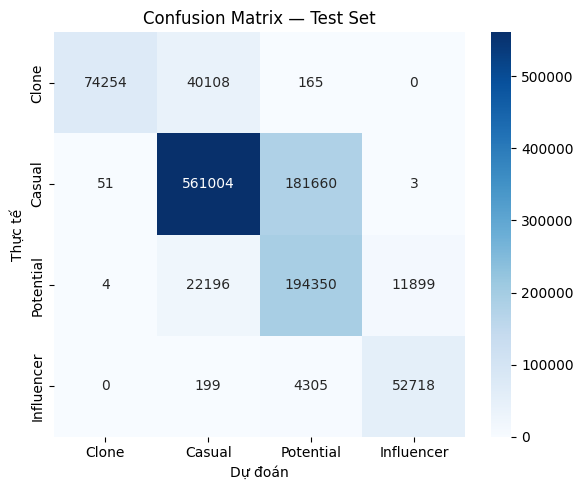

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    test_preds  = logits[data.test_mask].argmax(dim=1).cpu().numpy()
    test_truths = data.y[data.test_mask].cpu().numpy()

print('Kết quả trên Test Set:')
print(classification_report(
    test_truths, test_preds,
    target_names=['Clone/Spam', 'Casual', 'Potential', 'Influencer'],
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(test_truths, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clone', 'Casual', 'Potential', 'Influencer'],
            yticklabels=['Clone', 'Casual', 'Potential', 'Influencer'], ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontsize=12)
ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()